In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, ifftshift

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

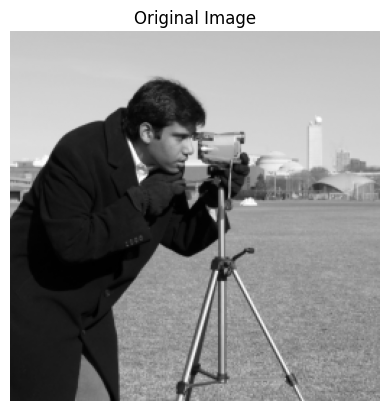

In [2]:
# Load cameraman image (grayscale)
image = data.camera()
image = resize(image, (256, 256))  # Resize for speed

# Get image size
M, N = image.shape

plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

In [3]:
# Sobel filters (spatial domain)
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

In [4]:
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape

    # Center coordinates
    cy, cx = ph // 2, pw // 2

    # Place kernel at center
    padded[cy - kh//2:cy - kh//2 + kh,
           cx - kw//2:cx - kw//2 + kw] = kernel

    # Shift + FFT
    return fft2(ifftshift(padded))

In [5]:
# FFT of image
F = fft2(image)

# FFT of Sobel filters (frequency domain)
Hx = center_embed_kernel(sobel_x, (M, N))
Hy = center_embed_kernel(sobel_y, (M, N))

In [6]:
# Apply filters
Fx = F * Hx
Fy = F * Hy

# Inverse FFT to get spatial results
sobel_x_image = np.real(ifft2(Fx))
sobel_y_image = np.real(ifft2(Fy))

In [7]:
# Gradient magnitude
sobel_magnitude = np.sqrt(sobel_x_image**2 + sobel_y_image**2)

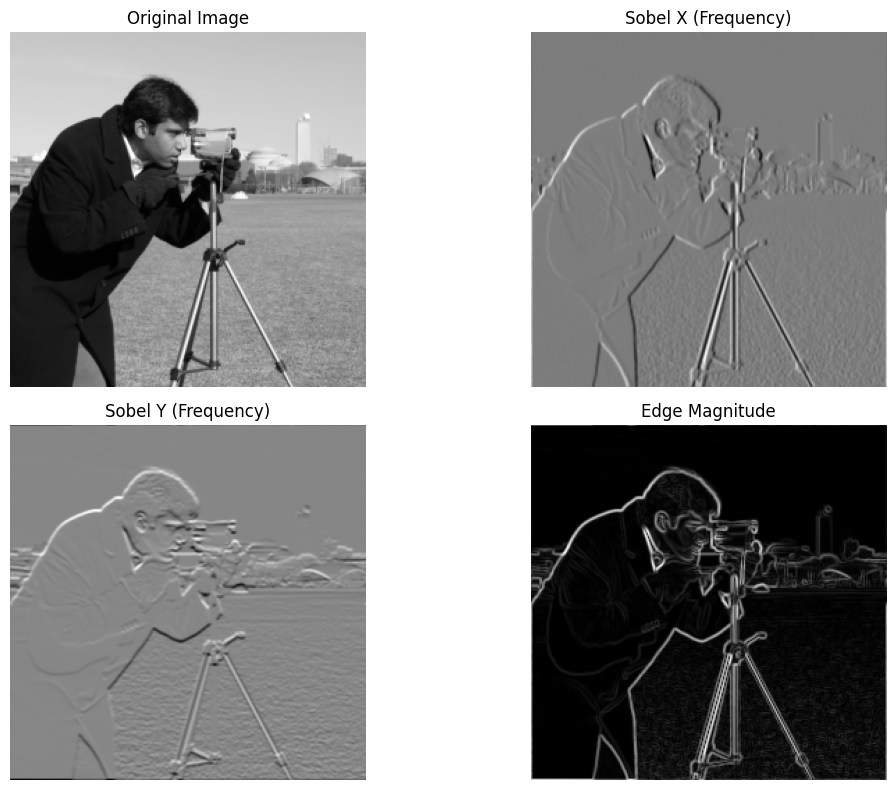

In [8]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(sobel_x_image, cmap='gray')
plt.title("Sobel X (Frequency)")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(sobel_y_image, cmap='gray')
plt.title("Sobel Y (Frequency)")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title("Edge Magnitude")
plt.axis('off')

plt.tight_layout()
plt.show()